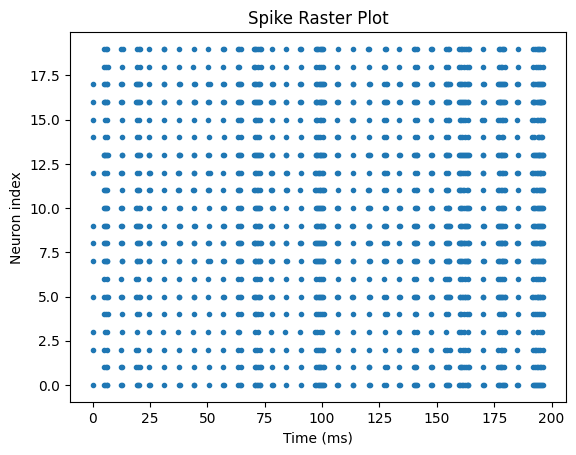

In [1]:
from brian2 import *
import matplotlib.pyplot as plt

# Avoid DLL compilation issue
prefs.codegen.target = "numpy"

start_scope()

N = 20
tau = 10*ms

# neuron equation
eqs = '''
dv/dt = (1 - v)/tau : 1
'''

# create neuron group
G = NeuronGroup(N, eqs, threshold='v>0.8', reset='v=0', method='exact')

# random initial voltage
G.v = 'rand()'

# connect neurons randomly
S = Synapses(G, G, on_pre='v_post += 0.2')
S.connect(p=0.3)

# monitors
spike_mon = SpikeMonitor(G)
state_mon = StateMonitor(G, 'v', record=0)

run(200*ms)

# spike raster plot
plt.figure()
plt.plot(spike_mon.t/ms, spike_mon.i, '.')
plt.xlabel("Time (ms)")
plt.ylabel("Neuron index")
plt.title("Spike Raster Plot")
plt.show()